In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# ============================================================
# Load all model results
# ============================================================

layer2a = pd.read_csv("data/layer2a_results.csv")
layer2b = pd.read_csv("data/layer2b_best_result.csv")
lstm = pd.read_csv("data/layer3_lstm_results.csv")
ews = pd.read_csv("data/ews_test_results.csv")

display(layer2a)
display(layer2b)
display(lstm)
display(ews)

,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,Pooled OLS,Observed test (2022-23),346,4.816,2.755,0.206,3.813,3.296,0.517
1,Entity Fixed Effects,Observed test (2022-23),346,4.914,2.698,0.173,3.813,3.639,0.174
2,Random Effects,Observed test (2022-23),346,4.816,2.755,0.206,3.813,3.296,0.517
3,Pooled OLS,COVID stress test (2020-21),346,9.095,6.780,-0.191,0.764,2.484,-1.719
4,Entity Fixed Effects,COVID stress test (2020-21),346,8.953,6.646,-0.154,0.764,2.876,-2.112
5,Random Effects,COVID stress test (2020-21),346,9.095,6.780,-0.191,0.764,2.484,-1.719


,Model,Feature_Set,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,Random Forest,Base + all volatility + country history,Observed test (2022-23),346,4.709,2.631,0.241,3.81,4.04,-0.22


,Model,Period,N,RMSE,MAE,R2,Mean_Actual,Mean_Predicted,Mean_Error
0,LSTM calibrated,Observed test (2022-23),346,5.022,2.829,0.136,3.81,2.95,0.86
1,LSTM calibrated,Year 2022,173,6.184,3.304,0.086,4.51,3.21,1.30
2,LSTM calibrated,Year 2023,173,3.492,2.355,0.217,3.12,2.69,0.42


,Model,Period,N,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Observed test (2022-23),346,0.841,0.878,0.792,0.833,0.923
1,Random Forest,Observed test (2022-23),346,0.827,0.809,0.855,0.831,0.920
2,Extra Trees,Observed test (2022-23),346,0.838,0.791,0.919,0.850,0.930
3,XGBoost,Observed test (2022-23),346,0.835,0.892,0.763,0.822,0.922


In [3]:
# ============================================================
# Regression model comparison
# ============================================================

regression_rows = []

best_2a = (
    layer2a[
        layer2a["Period"] == "Observed test (2022-23)"
    ]
    .sort_values("RMSE")
    .iloc[0]
)

best_2b = layer2b.iloc[0]

lstm_main = (
    lstm[
        lstm["Period"] == "Observed test (2022-23)"
    ]
    .iloc[0]
)

regression_rows.append({
    "Layer": "Layer 2a",
    "Model": best_2a["Model"],
    "Task": "GDP growth regression",
    "RMSE": best_2a["RMSE"],
    "MAE": best_2a["MAE"],
    "R2": best_2a["R2"],
})

regression_rows.append({
    "Layer": "Layer 2b",
    "Model": best_2b["Model"],
    "Task": "GDP growth regression",
    "RMSE": best_2b["RMSE"],
    "MAE": best_2b["MAE"],
    "R2": best_2b["R2"],
})

regression_rows.append({
    "Layer": "Layer 3",
    "Model": "LSTM",
    "Task": "GDP growth sequence regression",
    "RMSE": lstm_main["RMSE"],
    "MAE": lstm_main["MAE"],
    "R2": lstm_main["R2"],
})

regression_comparison = pd.DataFrame(regression_rows)

regression_comparison.to_csv(
    "data/final_regression_model_comparison.csv",
    index=False,
)

display(regression_comparison.sort_values("RMSE"))


,Layer,Model,Task,RMSE,MAE,R2
1,Layer 2b,Random Forest,GDP growth regression,4.709,2.631,0.241
0,Layer 2a,Pooled OLS,GDP growth regression,4.816,2.755,0.206
2,Layer 3,LSTM,GDP growth sequence regression,5.022,2.829,0.136


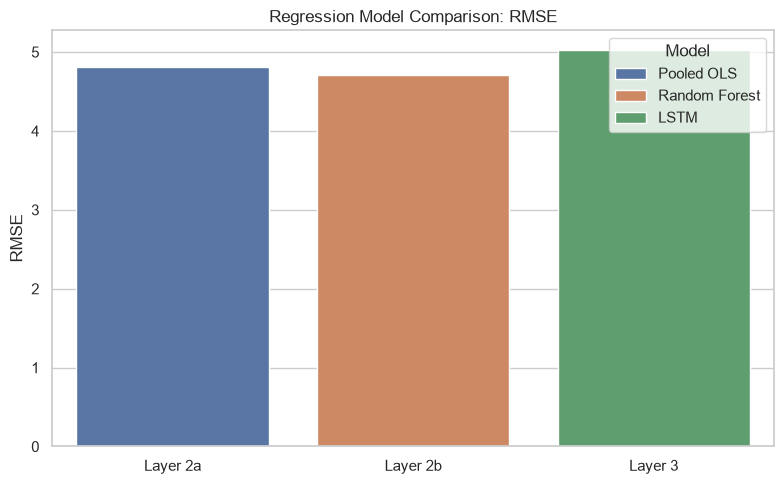

In [4]:
# ============================================================
# Regression comparison plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_comparison,
    x="Layer",
    y="RMSE",
    hue="Model",
)

plt.title("Regression Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xlabel("")
plt.tight_layout()

plt.savefig(
    "final_regression_rmse_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

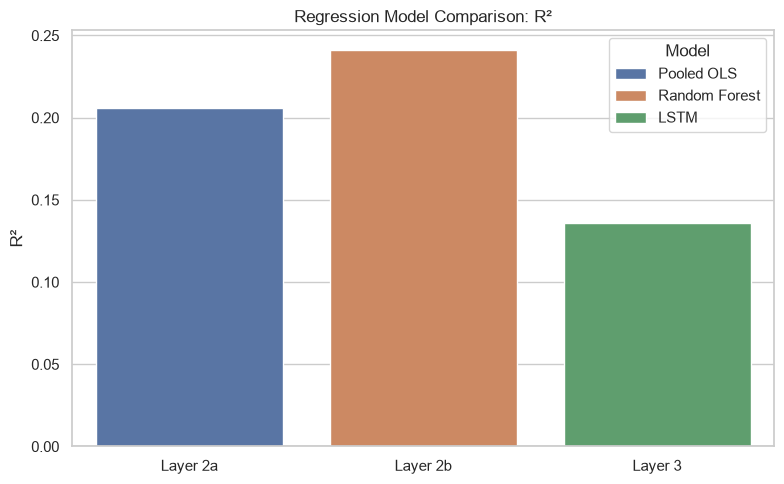

In [5]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=regression_comparison,
    x="Layer",
    y="R2",
    hue="Model",
)

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Regression Model Comparison: R²")
plt.ylabel("R²")
plt.xlabel("")
plt.tight_layout()

plt.savefig(
    "final_regression_r2_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [6]:
# ============================================================
# EWS classification comparison
# ============================================================

ews_comparison = ews.copy()

ews_comparison.to_csv(
    "data/final_ews_model_comparison.csv",
    index=False,
)

display(
    ews_comparison.sort_values(
        "ROC_AUC",
        ascending=False,
    )
)

,Model,Period,N,Accuracy,Precision,Recall,F1,ROC_AUC
2,Extra Trees,Observed test (2022-23),346,0.838,0.791,0.919,0.850,0.930
0,Logistic Regression,Observed test (2022-23),346,0.841,0.878,0.792,0.833,0.923
3,XGBoost,Observed test (2022-23),346,0.835,0.892,0.763,0.822,0.922
1,Random Forest,Observed test (2022-23),346,0.827,0.809,0.855,0.831,0.920


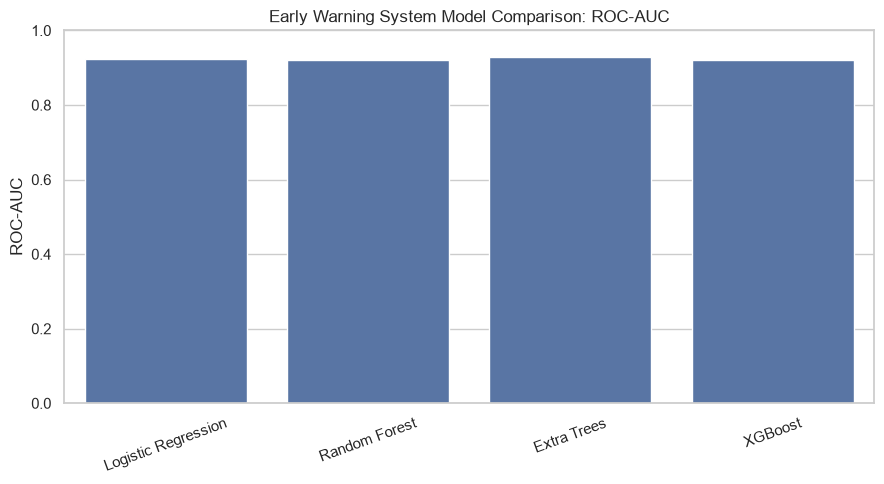

In [7]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=ews_comparison,
    x="Model",
    y="ROC_AUC",
)

plt.title("Early Warning System Model Comparison: ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "final_ews_roc_auc_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

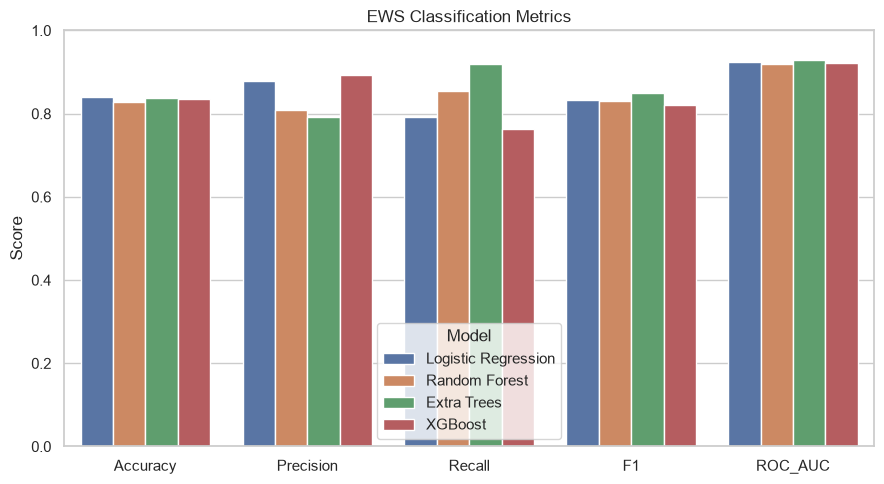

In [8]:
plt.figure(figsize=(9, 5))

ews_melt = ews_comparison.melt(
    id_vars=["Model"],
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    var_name="Metric",
    value_name="Score",
)

sns.barplot(
    data=ews_melt,
    x="Metric",
    y="Score",
    hue="Model",
)

plt.title("EWS Classification Metrics")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    "final_ews_metrics_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [9]:
# ============================================================
# Final project summary table
# ============================================================

best_ews = (
    ews_comparison
    .sort_values("ROC_AUC", ascending=False)
    .iloc[0]
)

summary = pd.DataFrame([
    {
        "Component": "Econometric Baseline",
        "Best_Model": best_2a["Model"],
        "Primary_Metric": "RMSE",
        "Score": best_2a["RMSE"],
        "Interpretation": "Interpretable baseline for GDP growth prediction",
    },
    {
        "Component": "Machine Learning Regression",
        "Best_Model": best_2b["Model"],
        "Primary_Metric": "RMSE",
        "Score": best_2b["RMSE"],
        "Interpretation": "Best exact GDP growth forecasting model",
    },
    {
        "Component": "LSTM",
        "Best_Model": "LSTM",
        "Primary_Metric": "RMSE",
        "Score": lstm_main["RMSE"],
        "Interpretation": "Sequence-learning benchmark, weaker than RF",
    },
    {
        "Component": "Early Warning System",
        "Best_Model": best_ews["Model"],
        "Primary_Metric": "ROC-AUC",
        "Score": best_ews["ROC_AUC"],
        "Interpretation": "Best high-instability risk detection layer",
    },
])

summary.to_csv(
    "data/final_project_model_summary.csv",
    index=False,
)

display(summary)

,Component,Best_Model,Primary_Metric,Score,Interpretation
0,Econometric Baseline,Pooled OLS,RMSE,4.816,Interpretable baseline for GDP growth prediction
1,Machine Learning Regression,Random Forest,RMSE,4.709,Best exact GDP growth forecasting model
2,LSTM,LSTM,RMSE,5.022,"Sequence-learning benchmark, weaker than RF"
3,Early Warning System,Extra Trees,ROC-AUC,0.930,Best high-instability risk detection layer
